# Project 7 - Stream Analysis
## Stream Analysis of the New York Times Articles and Comments Dataset

## Introduction

This project studies approximate stream-analysis methods on the New York Times Articles and Comments 2020 dataset. The goal is to implement streaming algorithms from scratch in Python and compare their outputs against exact baselines.

The dataset is interpreted as a stream of comment-related events. In particular, the project focuses on three tasks:

1. approximate article membership using a Bloom filter,
2. approximate distinct-user counting using the Flajolet-Martin algorithm,
3. approximate second-moment estimation using an AMS estimator.

All algorithms are implemented from scratch and evaluated on a sampled subset of the data for reproducibility and runtime control.

In [1]:
!pip install -q kaggle pandas numpy matplotlib

In [ ]:
from google.colab import files
files.upload()

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
import matplotlib.pyplot as plt

## Dataset

The project uses the New York Times Articles and Comments 2020 dataset from Kaggle. The dataset is downloaded dynamically during notebook execution using the Kaggle API.

For runtime reasons, the notebook uses sampled mode by default. However, the same approach can be applied to larger subsets or the full dataset.

In [5]:
!mkdir -p data
!kaggle datasets download -d benjaminawd/new-york-times-articles-comments-2020 -p data --force
!unzip -o "data/new-york-times-articles-comments-2020.zip" -d data

Dataset URL: https://www.kaggle.com/datasets/benjaminawd/new-york-times-articles-comments-2020
License(s): CC-BY-NC-SA-4.0
 99% 1.93G/1.95G [00:26<00:00, 52.8MB/s]
100% 1.95G/1.95G [00:26<00:00, 79.8MB/s]
Archive:  data/new-york-times-articles-comments-2020.zip
  inflating: data/nyt-articles-2020.csv  
  inflating: data/nyt-comments-2020.csv  
  inflating: data/nyt-comments-part0.csv  
  inflating: data/nyt-comments-part1.csv  
  inflating: data/nyt-comments-part2.csv  
  inflating: data/nyt-comments-part3.csv  
  inflating: data/nyt-comments-part4.csv  
  inflating: data/nyt-comments-part5.csv  
  inflating: data/nyt-comments-part6.csv  
  inflating: data/nyt-comments-part7.csv  
  inflating: data/nyt-comments-part8.csv  
  inflating: data/nyt-comments-part9.csv  
  inflating: data/test.csv           
  inflating: data/train.csv          


In [6]:
!ls -R data

data:
new-york-times-articles-comments-2020.zip  nyt-comments-part5.csv
nyt-articles-2020.csv			   nyt-comments-part6.csv
nyt-comments-2020.csv			   nyt-comments-part7.csv
nyt-comments-part0.csv			   nyt-comments-part8.csv
nyt-comments-part1.csv			   nyt-comments-part9.csv
nyt-comments-part2.csv			   test.csv
nyt-comments-part3.csv			   train.csv
nyt-comments-part4.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import random

from collections import Counter

In [8]:
comments_df = pd.read_csv("data/nyt-comments-2020.csv", low_memory=False)
print(comments_df.shape)
print(comments_df.columns.tolist())
comments_df.head()

(4986461, 23)
['commentID', 'status', 'commentSequence', 'userID', 'userDisplayName', 'userLocation', 'userTitle', 'commentBody', 'createDate', 'updateDate', 'approveDate', 'recommendations', 'replyCount', 'editorsSelection', 'parentID', 'parentUserDisplayName', 'depth', 'commentType', 'trusted', 'recommendedFlag', 'permID', 'isAnonymous', 'articleID']


,commentID,status,commentSequence,userID,userDisplayName,userLocation,userTitle,commentBody,createDate,updateDate,...,editorsSelection,parentID,parentUserDisplayName,depth,commentType,trusted,recommendedFlag,permID,isAnonymous,articleID
0,104387472,approved,104387472,60215558,magicisnotreal,earth,NaN,Here is something I think is fraudulent that v...,2020-01-01 01:05:46,2020-01-01 08:13:39,...,False,NaN,NaN,1,comment,0,0,104387472,False,nyt://article/69a7090b-9f36-569e-b5ab-b0ba5bb3...
1,104387873,approved,104387873,65691034,JD,Elko,NaN,@magicisnotreal I have used my VA loan option...,2020-01-01 01:52:25,2020-01-01 20:55:19,...,False,104387472.0,magicisnotreal,2,userReply,0,0,104387873,False,nyt://article/69a7090b-9f36-569e-b5ab-b0ba5bb3...
2,104387976,approved,104387976,65110053,ebmem,"Memphis, TN",NaN,@magi\n\nWhy would someone take out a VA loan ...,2020-01-01 02:06:05,2020-01-01 20:55:35,...,False,104387472.0,magicisnotreal,2,userReply,0,0,104387976,False,nyt://article/69a7090b-9f36-569e-b5ab-b0ba5bb3...
3,104390628,approved,104390628,60215558,magicisnotreal,earth,NaN,@JD\nOut here in the Alabama of the PNW they w...,2020-01-01 14:38:50,2020-01-01 20:56:46,...,False,104387873.0,magicisnotreal,2,userReply,0,0,104390628,False,nyt://article/69a7090b-9f36-569e-b5ab-b0ba5bb3...
4,104391463,approved,104391463,65691034,JD,Elko,NaN,@magicisnotreal just a guess but I doubt that...,2020-01-01 16:23:14,2020-01-01 16:25:57,...,False,104390628.0,magicisnotreal,2,userReply,0,0,104391463,False,nyt://article/69a7090b-9f36-569e-b5ab-b0ba5bb3...


## Data Preprocessing

The main working dataset for this project is the comments table. From the original dataset, only the fields needed for stream analysis are retained:

- `commentID`
- `userID`
- `articleID`
- `commentType`

Missing values are removed and the relevant columns are converted to string form for consistent processing.

Three streams are then derived:

- `user_stream` for distinct counting,
- `article_stream` for approximate membership,
- `comment_type_stream` for second-moment estimation.

In [9]:
stream_df = comments_df[["commentID", "userID", "articleID", "commentType"]].copy()

stream_df = stream_df.dropna()
stream_df["commentID"] = stream_df["commentID"].astype(str)
stream_df["userID"] = stream_df["userID"].astype(str)
stream_df["articleID"] = stream_df["articleID"].astype(str)
stream_df["commentType"] = stream_df["commentType"].astype(str)

USE_SAMPLE = True
SAMPLE_SIZE = 50000
RANDOM_SEED = 42

if USE_SAMPLE and len(stream_df) > SAMPLE_SIZE:
    stream_df = stream_df.sample(SAMPLE_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)

print(stream_df.shape)
stream_df.head()

(50000, 4)


,commentID,userID,articleID,commentType
0,110087908,60584754,nyt://article/41e70f52-ff22-507c-8021-b825e799...,comment
1,108591248,76796287,nyt://article/18d673af-1485-5fc9-9f31-5aaa9795...,comment
2,105569203,39572354,nyt://article/a2d95eaf-accf-5975-ada0-3a82620f...,comment
3,107022138,70515269,nyt://article/1d0ab86d-8cb9-5cf4-a015-57683337...,comment
4,109498523,101062631,nyt://article/b22d1a33-06b9-5a6e-a377-a464a425...,userReply


In [10]:
user_stream = stream_df["userID"].tolist()
article_stream = stream_df["articleID"].tolist()
comment_type_stream = stream_df["commentType"].tolist()

print("Number of stream items:", len(stream_df))
print("First 5 user IDs:", user_stream[:5])
print("First 5 article IDs:", article_stream[:5])
print("First 5 comment types:", comment_type_stream[:5])

Number of stream items: 50000
First 5 user IDs: ['60584754', '76796287', '39572354', '70515269', '101062631']
First 5 article IDs: ['nyt://article/41e70f52-ff22-507c-8021-b825e799c93b', 'nyt://article/18d673af-1485-5fc9-9f31-5aaa97953b4a', 'nyt://article/a2d95eaf-accf-5975-ada0-3a82620f9a5c', 'nyt://article/1d0ab86d-8cb9-5cf4-a015-57683337ce89', 'nyt://article/b22d1a33-06b9-5a6e-a377-a464a425288f']
First 5 comment types: ['comment', 'comment', 'comment', 'comment', 'userReply']


## Exact Baselines

Before applying approximate algorithms, exact reference values are computed:

- the true number of distinct users,
- the exact set of article IDs,
- the exact second frequency moment of the user stream,
- the exact second frequency moment of the comment-type stream.

These values are used to evaluate approximation quality.

In [11]:
from collections import Counter

exact_distinct_users = len(set(user_stream))

article_membership_set = set(article_stream)

comment_type_counts = Counter(comment_type_stream)
exact_second_moment_comment_type = sum(count ** 2 for count in comment_type_counts.values())

print("Exact distinct users:", exact_distinct_users)
print("Number of unique articles:", len(article_membership_set))
print("Comment type counts:", comment_type_counts)
print("Exact second moment for commentType:", exact_second_moment_comment_type)

Exact distinct users: 27123
Number of unique articles: 9448
Comment type counts: Counter({'comment': 28425, 'userReply': 21548, 'reporterReply': 27})
Exact second moment for commentType: 1272297658


In [12]:
user_counts = Counter(user_stream)
exact_second_moment_users = sum(count ** 2 for count in user_counts.values())

print("Number of unique users:", len(user_counts))
print("Exact second moment for user stream:", exact_second_moment_users)

top_10_users = user_counts.most_common(10)
print("Top 10 users by comment count:")
for user_id, count in top_10_users:
    print(user_id, count)

Number of unique users: 27123
Exact second moment for user stream: 282736
Top 10 users by comment count:
66788641 89
93082167 88
67892453 81
72967915 79
68938663 67
63483890 58
78358680 45
67780436 45
73444633 43
5646097 43


## Bloom Filter

The Bloom filter is used for approximate membership testing on article IDs. All unique article IDs are inserted into the filter. Membership is then tested on both known inserted items and synthetic non-member identifiers.

The Bloom filter guarantees no false negatives for inserted items, but it may return false positives for non-members.

In [13]:
def stable_hash(value, seed=0):
    text = f"{seed}:{value}".encode("utf-8")
    digest = hashlib.sha256(text).hexdigest()
    return int(digest, 16)

class BloomFilter:
    def __init__(self, size, num_hashes):
        self.size = size
        self.num_hashes = num_hashes
        self.bits = [0] * size

    def _hashes(self, item):
        for seed in range(self.num_hashes):
            yield stable_hash(item, seed) % self.size

    def add(self, item):
        for idx in self._hashes(item):
            self.bits[idx] = 1

    def contains(self, item):
        return all(self.bits[idx] == 1 for idx in self._hashes(item))

In [14]:
bloom_size = 50000
num_hashes = 5

bf = BloomFilter(size=bloom_size, num_hashes=num_hashes)

for article_id in article_membership_set:
    bf.add(article_id)

true_positive_checks = article_stream[:1000]
true_positives = sum(1 for x in true_positive_checks if bf.contains(x))

print("Inserted unique articles:", len(article_membership_set))
print("True positives out of 1000 known articles:", true_positives)

Inserted unique articles: 9448
True positives out of 1000 known articles: 1000


In [15]:
fake_article_ids = [f"fake_article_{i}" for i in range(1000)]
false_positives = sum(1 for x in fake_article_ids if bf.contains(x))
false_positive_rate = false_positives / len(fake_article_ids)

print("False positives:", false_positives)
print("False positive rate:", false_positive_rate)

False positives: 74
False positive rate: 0.074


## Flajolet-Martin Distinct Counting

The Flajolet-Martin algorithm is used to estimate the number of distinct users in the stream. The implementation relies on repeated hashing and counting trailing zeros in hash outputs.

The estimate is compared against the exact number of distinct users, and different numbers of hash functions are tested.

In [16]:
def trailing_zeros(value):
    if value == 0:
        return 64
    count = 0
    while (value & 1) == 0:
        count += 1
        value >>= 1
    return count

class FlajoletMartin:
    def __init__(self, num_hashes=16):
        self.num_hashes = num_hashes
        self.max_zeros = [0] * num_hashes

    def add(self, item):
        for i in range(self.num_hashes):
            h = stable_hash(item, i)
            tz = trailing_zeros(h)
            if tz > self.max_zeros[i]:
                self.max_zeros[i] = tz

    def estimate(self):
        estimates = [2 ** r for r in self.max_zeros]
        estimates.sort()
        mid = len(estimates) // 2
        if len(estimates) % 2 == 0:
            return (estimates[mid - 1] + estimates[mid]) / 2
        return estimates[mid]

In [17]:
fm = FlajoletMartin(num_hashes=32)

for user_id in user_stream:
    fm.add(user_id)

fm_estimate = fm.estimate()
fm_error = abs(fm_estimate - exact_distinct_users) / exact_distinct_users

print("Exact distinct users:", exact_distinct_users)
print("Flajolet-Martin estimate:", fm_estimate)
print("Relative error:", fm_error)
print("Max trailing zeros per hash:", fm.max_zeros)

Exact distinct users: 27123
Flajolet-Martin estimate: 32768.0
Relative error: 0.2081259447701213
Max trailing zeros per hash: [14, 16, 14, 17, 18, 14, 18, 15, 15, 16, 13, 13, 16, 13, 14, 15, 15, 14, 15, 17, 15, 18, 16, 13, 16, 19, 15, 15, 17, 17, 14, 15]


In [18]:
hash_settings = [4, 8, 16, 32, 64]
fm_results = []

for k in hash_settings:
    fm_model = FlajoletMartin(num_hashes=k)
    for user_id in user_stream:
        fm_model.add(user_id)
    estimate = fm_model.estimate()
    error = abs(estimate - exact_distinct_users) / exact_distinct_users
    fm_results.append((k, estimate, error))

for k, estimate, error in fm_results:
    print(f"num_hashes={k:>2} | estimate={estimate:.2f} | relative_error={error:.4f}")

num_hashes= 4 | estimate=40960.00 | relative_error=0.5102
num_hashes= 8 | estimate=49152.00 | relative_error=0.8122
num_hashes=16 | estimate=32768.00 | relative_error=0.2081
num_hashes=32 | estimate=32768.00 | relative_error=0.2081
num_hashes=64 | estimate=32768.00 | relative_error=0.2081


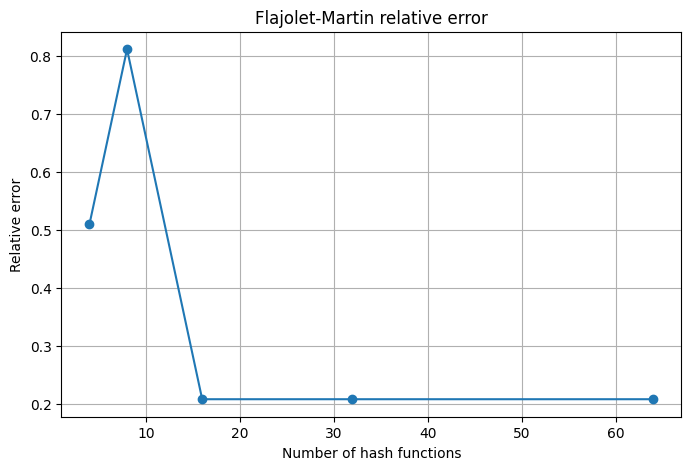

In [19]:
fm_df = pd.DataFrame(fm_results, columns=["num_hashes", "estimate", "relative_error"])

plt.figure(figsize=(8, 5))
plt.plot(fm_df["num_hashes"], fm_df["relative_error"], marker="o")
plt.xlabel("Number of hash functions")
plt.ylabel("Relative error")
plt.title("Flajolet-Martin relative error")
plt.grid(True)
plt.show()

## AMS Second-Moment Estimation

The AMS estimator is used to approximate the second frequency moment of the stream, which reflects how concentrated the stream distribution is.

This implementation is evaluated on the user stream and compared against the exact second moment. Multiple counter settings are tested to study parameter sensitivity.

In [20]:
class AMSEstimator:
    def __init__(self, num_counters=25, seed=42):
        self.num_counters = num_counters
        self.seed = seed
        random.seed(seed)
        self.sign_maps = [{} for _ in range(num_counters)]

    def _sign(self, row, item):
        if item not in self.sign_maps[row]:
            self.sign_maps[row][item] = random.choice([-1, 1])
        return self.sign_maps[row][item]

    def estimate(self, stream):
        z = [0] * self.num_counters

        for item in stream:
            for i in range(self.num_counters):
                z[i] += self._sign(i, item)

        estimates = [value * value for value in z]
        estimates.sort()
        mid = len(estimates) // 2
        if len(estimates) % 2 == 0:
            return (estimates[mid - 1] + estimates[mid]) / 2
        return estimates[mid]

In [21]:
ams = AMSEstimator(num_counters=25, seed=42)
ams_estimate_users = ams.estimate(user_stream)
ams_error_users = abs(ams_estimate_users - exact_second_moment_users) / exact_second_moment_users

print("Exact second moment for user stream:", exact_second_moment_users)
print("AMS estimate for user stream:", ams_estimate_users)
print("Relative error:", ams_error_users)

Exact second moment for user stream: 282736
AMS estimate for user stream: 66564
Relative error: 0.7645718974591138


In [22]:
counter_settings = [5, 10, 25, 50, 100]
ams_results = []

for c in counter_settings:
    ams_model = AMSEstimator(num_counters=c, seed=42)
    estimate = ams_model.estimate(user_stream)
    error = abs(estimate - exact_second_moment_users) / exact_second_moment_users
    ams_results.append((c, estimate, error))

for c, estimate, error in ams_results:
    print(f"num_counters={c:>3} | estimate={estimate:.2f} | relative_error={error:.4f}")

num_counters=  5 | estimate=322624.00 | relative_error=0.1411
num_counters= 10 | estimate=145928.00 | relative_error=0.4839
num_counters= 25 | estimate=66564.00 | relative_error=0.7646
num_counters= 50 | estimate=201188.00 | relative_error=0.2884
num_counters=100 | estimate=90650.00 | relative_error=0.6794


## Results Discussion

The Bloom filter achieved stable behavior, correctly identifying all tested inserted article IDs while producing a moderate false positive rate on synthetic non-members.

The Flajolet-Martin estimator produced a reasonable approximation of the true number of distinct users. Its error decreased compared to very small hash settings, although improvements plateaued beyond a certain point.

The AMS estimator showed high variance and sensitivity to the number of counters. This suggests that while the method is attractive in theory for streaming settings, its practical behavior can be unstable without careful tuning.

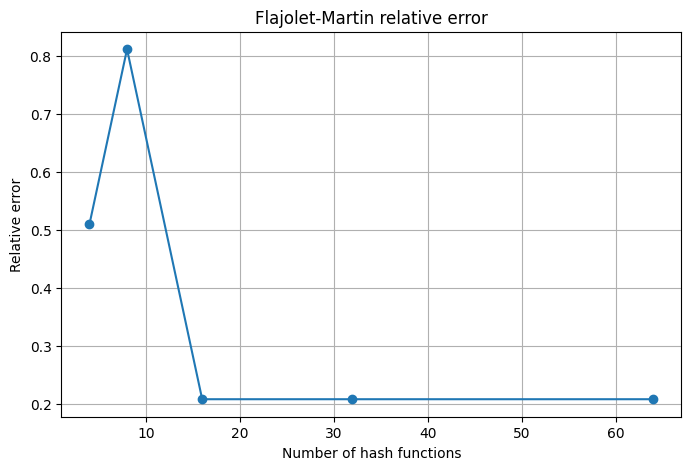

In [23]:
fm_df = pd.DataFrame(fm_results, columns=["num_hashes", "estimate", "relative_error"])

plt.figure(figsize=(8, 5))
plt.plot(fm_df["num_hashes"], fm_df["relative_error"], marker="o")
plt.xlabel("Number of hash functions")
plt.ylabel("Relative error")
plt.title("Flajolet-Martin relative error")
plt.grid(True)
plt.show()

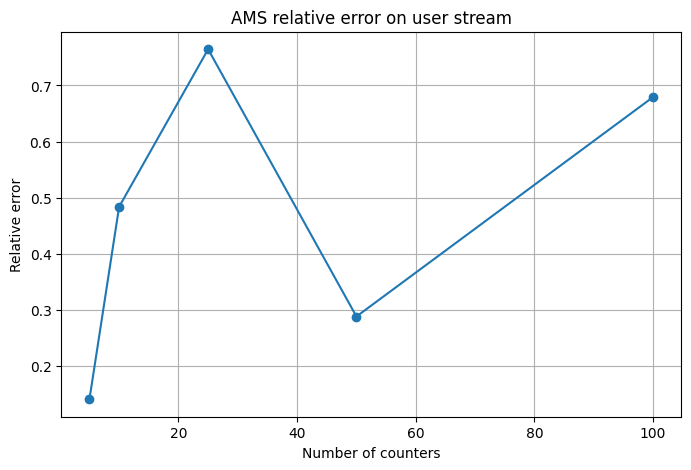

In [24]:
ams_df = pd.DataFrame(ams_results, columns=["num_counters", "estimate", "relative_error"])

plt.figure(figsize=(8, 5))
plt.plot(ams_df["num_counters"], ams_df["relative_error"], marker="o")
plt.xlabel("Number of counters")
plt.ylabel("Relative error")
plt.title("AMS relative error on user stream")
plt.grid(True)
plt.show()

In [25]:
results = pd.DataFrame([
    {
        "Algorithm": "Bloom Filter",
        "Task": "Approximate article membership",
        "Exact Value": "9448 inserted articles",
        "Estimated Value": "1000/1000 known positives, 74/1000 false positives",
        "Relative Error": "0.074 false positive rate"
    },
    {
        "Algorithm": "Flajolet-Martin",
        "Task": "Distinct user counting",
        "Exact Value": exact_distinct_users,
        "Estimated Value": fm_estimate,
        "Relative Error": fm_error
    },
    {
        "Algorithm": "AMS Estimator",
        "Task": "Second moment of user stream",
        "Exact Value": exact_second_moment_users,
        "Estimated Value": ams_estimate_users,
        "Relative Error": ams_error_users
    }
])

results

,Algorithm,Task,Exact Value,Estimated Value,Relative Error
0,Bloom Filter,Approximate article membership,9448 inserted articles,"1000/1000 known positives, 74/1000 false posit...",0.074 false positive rate
1,Flajolet-Martin,Distinct user counting,27123,32768.0,0.208126
2,AMS Estimator,Second moment of user stream,282736,66564,0.764572


## Conclusion

This project implemented three stream-analysis algorithms from scratch on the New York Times comments dataset: a Bloom filter, a Flajolet-Martin distinct counter, and an AMS second-moment estimator.

The experiments show that approximate stream methods can produce useful results with limited memory, but their accuracy depends on both the algorithm and the parameter settings. Among the tested methods, the Bloom filter gave the most stable practical performance, while Flajolet-Martin provided a reasonable distinct-count estimate. The AMS estimator was less stable, highlighting the importance of empirical evaluation when using approximate streaming methods.